# Dim별 검색 성능 막대그래프

이 노트북은 `run_benchmark.sh release search knn` 실행 후 생성된 검색 메트릭 CSV를 읽어
dim 별로 다음 4개 지표를 막대그래프로 그립니다.

- CPU time: `mean_cpu_us`
- IO time: `mean_disk_idle_us`
- IO us: `mean_io_us`
- Recall: `recall`

In [27]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# Notebook 기준 폴더: anns/starling/scripts
BASE_DIR = Path('../indices')

# run_benchmark.sh에서 생성되는 검색 메트릭 CSV만 탐색
# search_*.csv 중 round_*, result_*_results.csv 등은 제외
csv_files = []
for p in BASE_DIR.rglob('search/*.csv'):
    name = p.name
    if not name.startswith('search_'):
        continue
    if name.startswith('round_') or name.startswith('result_'):
        continue
    csv_files.append(p)

print(f'Found {len(csv_files)} search metric CSV files')
for p in csv_files[:10]:
    print('-', p)

Found 7 search metric CSV files
- ../indices/msmarco_nomic_32_M32_R32_L50_B0.008/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_nomic_512_M32_R32_L50_B0.128/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_nomic_128_M32_R32_L50_B0.032/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_nomic_64_M32_R32_L50_B0.016/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_nomic_256_M32_R32_L50_B0.064/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_nomic_768_M32_R32_L50_B0.192/search/search_SQ0_K10_CACHE0_BW2_T1_MEML10_MEMK_MEM_USE

In [28]:
def infer_dim_from_path(path: Path):
    s = str(path)

    # 예: msmarco_nomic_512_M32_R32_L50_B0.128/search/...
    m = re.search(r'_([0-9]+)_M[0-9]+_R[0-9]+_L[0-9]+_B', s)
    if m:
        return int(m.group(1))

    # 추가 패턴 후보
    m = re.search(r'mrl([0-9]+)', s)
    if m:
        return int(m.group(1))

    return None

required_cols = {
    'mean_cpu_us',
    'mean_disk_idle_us',
    'mean_io_us',
    'recall',
}

rows = []
for f in csv_files:
    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f'[skip] failed to read {f}: {e}')
        continue

    if not required_cols.issubset(df.columns):
        print(f'[skip] missing columns in {f}')
        continue

    dim = infer_dim_from_path(f)
    if dim is None:
        print(f'[skip] cannot infer dim from path: {f}')
        continue

    # 파일 내 여러 L 행 중 recall이 최대인 행을 대표로 선택
    row = df.sort_values(['recall', 'L'], ascending=[False, False]).iloc[0].to_dict()
    row['dim'] = dim
    row['source_file'] = str(f)
    rows.append(row)

if not rows:
    raise RuntimeError('No valid search metric CSV rows found. Check BASE_DIR and CSV files.')

summary = pd.DataFrame(rows)

# dim당 여러 실행이 있으면 recall 기준 최선 행을 사용
summary = (
    summary.sort_values(['dim', 'recall', 'L'], ascending=[True, False, False])
    .groupby('dim', as_index=False)
    .first()
    .sort_values('dim')
)

display(summary[['dim', 'L', 'beamwidth', 'mean_cpu_us', 'mean_disk_idle_us', 'mean_io_us', 'recall']])

,dim,L,beamwidth,mean_cpu_us,mean_disk_idle_us,mean_io_us,recall
0,16,100.0,2.0,4583.56,3772.05,4443.31,3.124
1,32,100.0,2.0,4794.80,4073.02,4647.03,15.376
2,64,100.0,2.0,3349.63,2780.09,3214.36,39.323
3,128,100.0,2.0,4744.37,4156.67,4570.47,55.409
4,256,100.0,2.0,5432.54,4886.69,5220.66,67.728
5,512,100.0,2.0,6769.68,6256.13,6435.27,79.206
6,768,100.0,2.0,6779.47,6238.47,6408.15,92.836


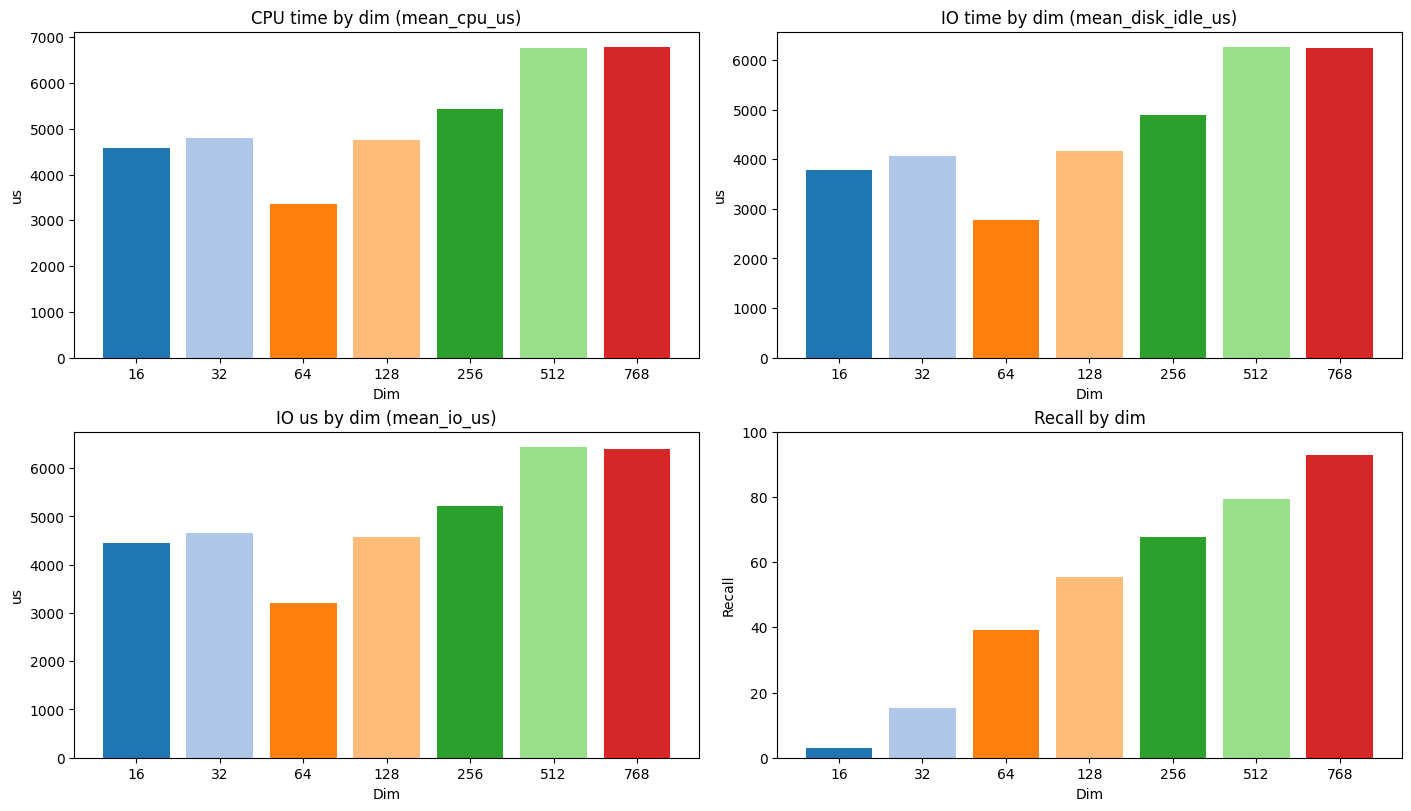

In [29]:
plot_df = summary.sort_values('dim').copy()
x_labels = plot_df['dim'].astype(str).tolist()
x = range(len(plot_df))

# 각 dim에 고유한 색상을 할당하고 모든 subplot에서 동일하게 사용
colors = plt.cm.tab20(range(len(plot_df)))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].bar(x, plot_df['mean_cpu_us'], color=colors)
axes[0, 0].set_title('CPU time by dim (mean_cpu_us)')
axes[0, 0].set_xticks(list(x), x_labels)
axes[0, 0].set_xlabel('Dim')
axes[0, 0].set_ylabel('us')

axes[0, 1].bar(x, plot_df['mean_disk_idle_us'], color=colors)
axes[0, 1].set_title('IO time by dim (mean_disk_idle_us)')
axes[0, 1].set_xticks(list(x), x_labels)
axes[0, 1].set_xlabel('Dim')
axes[0, 1].set_ylabel('us')

axes[1, 0].bar(x, plot_df['mean_io_us'], color=colors)
axes[1, 0].set_title('IO us by dim (mean_io_us)')
axes[1, 0].set_xticks(list(x), x_labels)
axes[1, 0].set_xlabel('Dim')
axes[1, 0].set_ylabel('us')

axes[1, 1].bar(x, plot_df['recall'], color=colors)
axes[1, 1].set_title('Recall by dim')
axes[1, 1].set_xticks(list(x), x_labels)
axes[1, 1].set_xlabel('Dim')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_ylim(0, 100 if plot_df['recall'].max() > 1.5 else 1.0)

plt.show()